In [1]:
from src.pipelines.bcf_pipelines import run_bcf_classification, run_bcf_regression
from src.llm.gemini_explainer import explicar_con_gemini
import matplotlib.pyplot as ptl

csv_path = "data\\BCF\\Grisoni_et_al_2016_EnvInt88.csv"

# CLASIFICACIÓN
bcf_clf = run_bcf_classification(csv_path)
print("Accuracy:", bcf_clf.accuracy)
print(bcf_clf.report)

Accuracy: 0.6923076923076923
              precision    recall  f1-score   support

           1       0.73      0.81      0.77       115
           2       0.69      0.69      0.69        16
           3       0.60      0.48      0.53        64

    accuracy                           0.69       195
   macro avg       0.67      0.66      0.66       195
weighted avg       0.68      0.69      0.69       195



c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


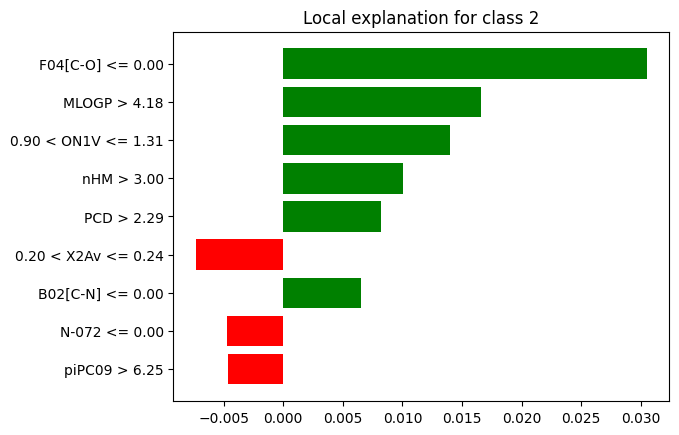

In [2]:
# ejemplo de explicación local con LIME
idx = 0
instance = bcf_clf.X_test.iloc[idx].values
lime_exp = bcf_clf.lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=bcf_clf.model.predict_proba,
    num_features=len(bcf_clf.X_test.columns),
)

fig = lime_exp.as_pyplot_figure()
ptl.close(fig)
fig

ExactExplainer explainer: 196it [01:03,  2.87it/s]                         


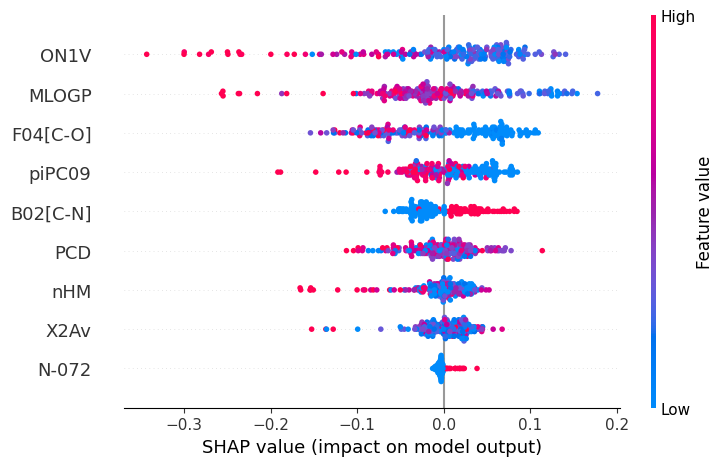

In [3]:
# SHAP local
import shap

shap_values = bcf_clf.shap_explainer(bcf_clf.X_test)
shap_local = shap_values[..., idx]
shap.plots.beeswarm(shap_local)

In [4]:
# LLM
texto = explicar_con_gemini(
    shap_local=shap_local,
    shap_global=shap_values,
    lime_exp=lime_exp,
    pred=bcf_clf.y_pred[idx],
    task_type="clasificación BCF",
    domain="IA",
    expertise_level="beginner",
)
print(texto)


¡Hola! Veo que eres un usuario principiante en el dominio de la Inteligencia Artificial y quieres entender una predicción de bioconcentración. ¡Con gusto te ayudo a traducir estos resultados técnicos a algo claro y útil!

Tu modelo de IA predijo que la molécula que analizamos pertenece a la **Clase de Bioconcentración 2**. Esto significa que se espera que esta molécula se acumule en los organismos a un nivel intermedio.

Para entender por qué el modelo hizo esta predicción, vamos a ver qué características de la molécula fueron las más importantes. Imagina que el modelo está buscando "pistas" en la molécula para decidir su clase.

Lamentablemente, algunos de los detalles específicos de la explicación local de esta molécula no están completos en los datos que me proporcionaste (hay partes que dicen "..."), lo que impide ver todas las "pistas" que consideró el modelo para esta molécula en particular. Sin embargo, basándonos en lo que sí podemos ver y en el conocimiento general sobre cómo 